C:\Users\ASHOKA MS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to C:\Users\ASHOKA
[nltk_data]     MS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Loading weights: 100%|██████████████████████████████████| 103/103 [00:00<00:00, 124.55it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



========== RESULTS ==========

Similarity Score Array:
[0.62, 0.387, 0.334, -0.012, 0.28, 0.417, 0.283, 0.343, 0.303, 0.216, 0.393, 0.159, 0.132, 0.262, 0.595, 0.57, 0.301, 0.19, 0.349, 0.154, 0.097, 0.528, 0.666, 0.648, 0.024, 0.251, 0.077, 0.076, 0.087, 0.211, 0.272, 0.191, 0.34, 0.257, 0.048, 0.279, 0.535, 0.183, 0.476, 0.292, 0.255, 0.153, 0.45, 0.525, 0.813, 0.21, 0.379, 0.625, 0.257, 0.549, 0.165, 0.245, 0.333, 0.544, 0.495, 0.38, 0.495, -0.01, 0.23, 0.144, 0.097, 0.71, 0.631, 0.124, 0.452, 0.571, 0.362, 0.471, 0.249, 0.175, 0.547, 0.64, 0.316, 0.306, 0.362, 0.327, 0.412, 0.562, 0.542, 0.655, 0.701, 0.525, 0.494, 0.539, 0.472, 0.502, 0.584, 0.415, 0.478, 0.551, 0.586, 0.246, 0.275, 0.443, 0.43, 0.284, 0.628, 0.543, 0.297, 0.222, 0.396, 0.603, 0.559, 0.575, 0.452, 0.277, 0.07, 0.187, 0.082, 0.2, 0.28, 0.513, 0.327, 0.637, 0.344, 0.28, 0.571, 0.239, 0.039, 0.298, 0.255, 0.355, 0.265]

Mean similarity: 0.362
Std deviation: 0.183
Threshold: 0.18

Detected Boundary Indices:
[4, 12, 1

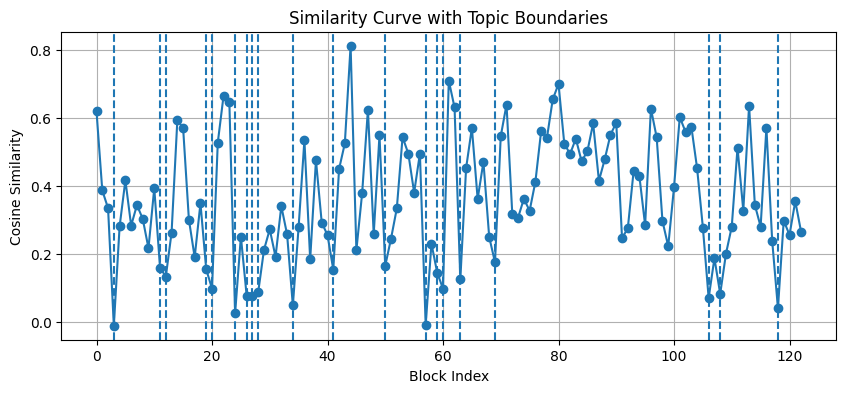

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nltk

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize

nltk.download('punkt')


TRANSCRIPT_FILE = "datasets/transcripts/audio1.txt"
BLOCK_SIZE = 5   # sentences per block

# load SBERT model
model = SentenceTransformer("all-MiniLM-L6-v2")


#split
def get_blocks(text):
    sentences = sent_tokenize(text)

    # fallback if punctuation missing (common in transcripts)
    if len(sentences) <= 1:
        sentences = text.split(". ")
        sentences = [s.strip() for s in sentences if s.strip()]

    blocks = [
        " ".join(sentences[i:i+BLOCK_SIZE])
        for i in range(0, len(sentences), BLOCK_SIZE)
    ]

    return blocks


# similarity
def compute_similarity(blocks):
    if len(blocks) < 2:
        return []

    embeddings = model.encode(blocks)

    similarities = [
        float(cosine_similarity([embeddings[i]], [embeddings[i+1]])[0][0])
        for i in range(len(embeddings) - 1)
    ]

    return similarities


# boundary detection
def detect_boundaries(similarities):

    mean = np.mean(similarities)
    std = np.std(similarities)

    threshold = mean - std

    boundaries = [
        i+1 for i, s in enumerate(similarities)
        if s < threshold
    ]

    return boundaries, mean, std, threshold


# segments creation
def create_segments(blocks, boundaries):
    segments = []
    start = 0

    for b in boundaries:
        segments.append(" ".join(blocks[start:b]))
        start = b

    segments.append(" ".join(blocks[start:]))

    return segments


# vizual graphs
def plot_similarity(similarities, boundaries):
    plt.figure(figsize=(10,4))
    plt.plot(similarities, marker='o')

    # mark boundaries
    for b in boundaries:
        plt.axvline(x=b-1, linestyle='--')

    plt.title("Similarity Curve with Topic Boundaries")
    plt.xlabel("Block Index")
    plt.ylabel("Cosine Similarity")
    plt.grid(True)
    plt.show()



with open(TRANSCRIPT_FILE, "r", encoding="utf-8") as f:
    text = f.read()

blocks = get_blocks(text)
similarities = compute_similarity(blocks)

boundaries, mean, std, threshold = detect_boundaries(similarities)
segments = create_segments(blocks, boundaries)


print("\n========== RESULTS ==========\n")

print("Similarity Score Array:")
print([round(s,3) for s in similarities])

print("\nMean similarity:", round(mean,3))
print("Std deviation:", round(std,3))
print("Threshold:", round(threshold,3))

print("\nDetected Boundary Indices:")
print(boundaries)

print("\nFinal Segmented Transcript:\n")

for i, seg in enumerate(segments, 1):
    print(f"--- Segment {i} ---")
    print(seg[:400])   # preview
    print()

# visualization
plot_similarity(similarities, boundaries)

[nltk_data] Downloading package punkt to C:\Users\ASHOKA
[nltk_data]     MS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Loading weights: 100%|█████████████████████| 103/103 [00:00<00:00, 171.83it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Similarity Score Array:
[0.602, 0.448]

Mean similarity: 0.525
Std deviation: 0.077
Threshold (mean - std): 0.448

Detected Boundary Indices:
[]

Final Segmented Transcript:

--- Segment 1 ---
when it comes to the question of economy which is going to benefit everybody the
politics cannot be so disrupt Once Upon a Time prime minister Rajiv Gandhi said
if I send one rupee to the beneficiary he ends up getting only 15 P adopting
technology Prime Ministers ensured that that kind of leakage doesn't happen one
rup sent is one Rupee received o



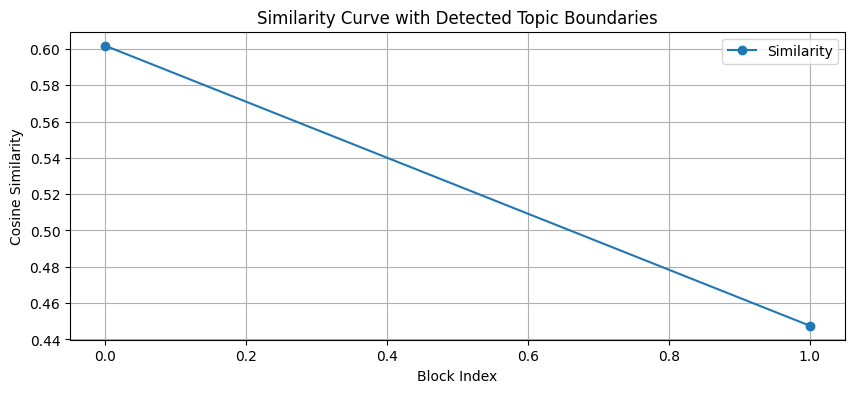

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import nltk

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize

nltk.download('punkt')


TRANSCRIPT_FILE = "datasets/transcripts/audio13.txt"
BLOCK_SIZE = 5   # sentences per block

# load SBERT
model = SentenceTransformer("all-MiniLM-L6-v2")


# CREATE BLOCKS
def create_blocks(text):
    sentences = sent_tokenize(text)

    # fallback if punctuation missing
    if len(sentences) <= 1:
        sentences = text.split(". ")
        sentences = [s.strip() for s in sentences if s.strip()]

    blocks = [
        " ".join(sentences[i:i+BLOCK_SIZE])
        for i in range(0, len(sentences), BLOCK_SIZE)
    ]

    return blocks


#  COMPUTE SIMILARITY 
def compute_similarity(blocks):
    if len(blocks) < 2:
        return []

    embeddings = model.encode(blocks)

    similarities = [
        float(cosine_similarity([embeddings[i]], [embeddings[i+1]])[0][0])
        for i in range(len(embeddings)-1)
    ]

    return similarities


#  DETECT BOUNDARIES 
def detect_boundaries(similarities):
    mean = np.mean(similarities)
    std = np.std(similarities)

    threshold = mean - std

    boundaries = [
        i+1 for i, s in enumerate(similarities)
        if s < threshold
    ]

    return boundaries, mean, std, threshold


# SEGMENT TRANSCRIPT 
def segment_transcript(blocks, boundaries):
    segments = []
    start = 0

    for b in boundaries:
        segments.append(" ".join(blocks[start:b]))
        start = b

    segments.append(" ".join(blocks[start:]))

    return segments


#  VISUAL CHECK 
def plot_similarity(similarities, boundaries):
    plt.figure(figsize=(10,4))
    plt.plot(similarities, marker='o', label="Similarity")

    # mark boundaries
    for b in boundaries:
        plt.axvline(x=b-1, linestyle='--', label="Boundary")

    plt.title("Similarity Curve with Detected Topic Boundaries")
    plt.xlabel("Block Index")
    plt.ylabel("Cosine Similarity")
    plt.grid(True)
    plt.legend()
    plt.show()


with open(TRANSCRIPT_FILE, "r", encoding="utf-8") as f:
    transcript = f.read()

blocks = create_blocks(transcript)
similarities = compute_similarity(blocks)

boundaries, mean, std, threshold = detect_boundaries(similarities)
segments = segment_transcript(blocks, boundaries)

# ===== OUTPUT =====
print("\nSimilarity Score Array:")
print([round(s,3) for s in similarities])

print("\nMean similarity:", round(mean,3))
print("Std deviation:", round(std,3))
print("Threshold (mean - std):", round(threshold,3))

print("\nDetected Boundary Indices:")
print(boundaries)

print("\nFinal Segmented Transcript:\n")

for i, seg in enumerate(segments, 1):
    print(f"--- Segment {i} ---")
    print(seg[:350])
    print()

# ===== VISUAL CHECK =====
plot_similarity(similarities, boundaries)